Ссылка на скачивание датасета с данными о пассажирах Титаника: [https://www.kaggle.com/competitions/titanic/data?select=train.csv].

Датасет «Титаник» содержит данные пассажиров корабля. Конечная цель — построить модель, которая лучшим образом сможет предсказать, остался пассажир в живых или нет.

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [112]:
df_original = df.copy()
print("Shape: ", df.shape)
print("Columns: ", df.columns)
print("Data types:\n", df.dtypes)

Shape:  (891, 12)
Columns:  Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')
Data types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [113]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [114]:

df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [115]:

df.sample(n=10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
82,83,1,3,"McDermott, Miss. Brigdet Delia",female,NaN,0,0,330932,7.7875,NaN,Q
347,348,1,3,"Davison, Mrs. Thomas Henry (Mary E Finck)",female,NaN,1,0,386525,16.1000,NaN,S
440,441,1,2,"Hart, Mrs. Benjamin (Esther Ada Bloomfield)",female,45.0,1,1,F.C.C. 13529,26.2500,NaN,S
248,249,1,1,"Beckwith, Mr. Richard Leonard",male,37.0,1,1,11751,52.5542,D35,S
66,67,1,2,"Nye, Mrs. (Elizabeth Ramell)",female,29.0,0,0,C.A. 29395,10.5000,F33,S
427,428,1,2,"Phillips, Miss. Kate Florence (""Mrs Kate Louis...",female,19.0,0,0,250655,26.0000,NaN,S
575,576,0,3,"Patchett, Mr. George",male,19.0,0,0,358585,14.5000,NaN,S
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
618,619,1,2,"Becker, Miss. Marion Louise",female,4.0,2,1,230136,39.0000,F4,S
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C


In [116]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [117]:
df.describe(include='object')

C:\Users\Kseniya Morozova\AppData\Local\Temp\ipykernel_16288\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [118]:
print("Missing values count:\n", df.isnull().sum())

Missing values count:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [119]:
perMis = df.isnull().sum() / df.shape[0] * 100
print("Missing data percent:\n", perMis)

Missing data percent:
 PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


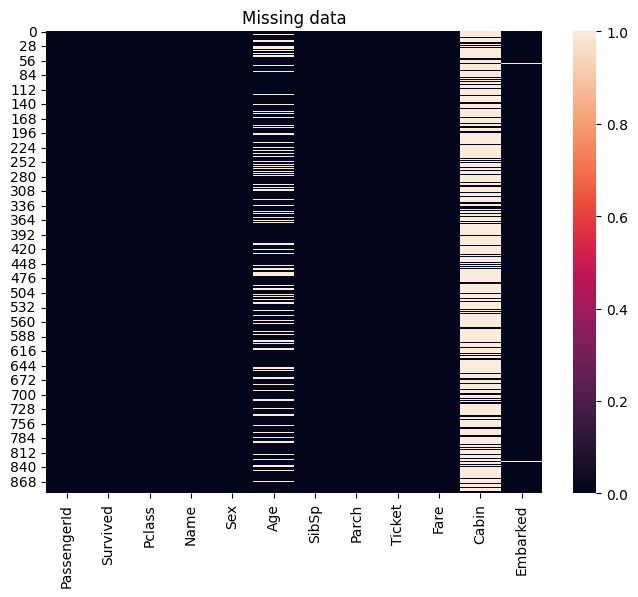

In [120]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.isnull())
plt.title("Missing data")
plt.show()

In [121]:
print("Duplicated data count:", df.duplicated().sum())
print("Duplicated data:", df[df.duplicated()])

Duplicated data count: 0
Duplicated data: Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []


In [122]:
print(df['Sex'].unique())
print(df['Sex'].value_counts())
print(df['Pclass'].unique())
print(df['Pclass'].value_counts())
print(df['Embarked'].unique())
print(df['Embarked'].value_counts())

<StringArray>
['male', 'female']
Length: 2, dtype: str
Sex
male      577
female    314
Name: count, dtype: int64
[3 1 2]
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


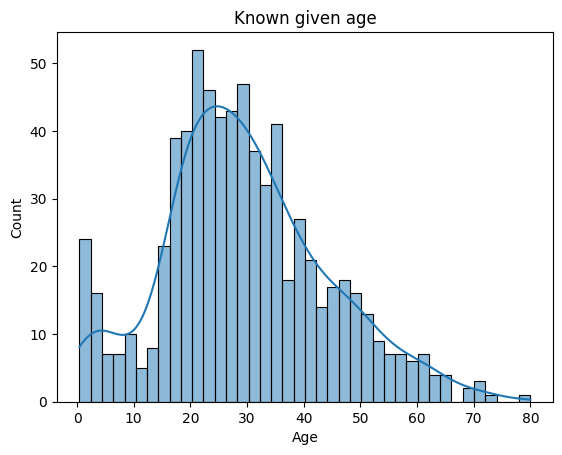

In [123]:
plt.figure()
sns.histplot(df["Age"], bins=40, kde=True)
plt.title("Known given age")
plt.show()

In [124]:
for s in ['Age', 'Fare', 'SibSp', 'Parch']:
    print(f"Column '{s}'")
    print(f"Min: {df[s].dropna().min()}")
    print(f"Max: {df[s].dropna().max()}")
    print(f"Mean: {df[s].dropna().mean()}")
    print(f"Median: {df[s].dropna().median()}")

Column 'Age'
Min: 0.42
Max: 80.0
Mean: 29.69911764705882
Median: 28.0
Column 'Fare'
Min: 0.0
Max: 512.3292
Mean: 32.204207968574636
Median: 14.4542
Column 'SibSp'
Min: 0
Max: 8
Mean: 0.5230078563411896
Median: 0.0
Column 'Parch'
Min: 0
Max: 6
Mean: 0.38159371492704824
Median: 0.0


In [125]:
#print(np.percentile(df['Fare'], [5, 25, 50, 75, 95]))
print("Percentiles for column 'Fare'")
for i in [5, 25, 50, 75, 95]:
    print(f"{i}th percentile: {np.percentile(df['Fare'], i)}")

Percentiles for column 'Fare'
5th percentile: 7.225
25th percentile: 7.9104
50th percentile: 14.4542
75th percentile: 31.0
95th percentile: 112.07915


In [126]:
for s in ['Age', 'Fare', 'SibSp', 'Parch']:
    print(f"Column '{s}'")
    print(f"Variance: {df[s].dropna().var()}") # дисперсия — разброс значений вокруг среднего
    print(f"Skewness: {df[s].dropna().skew()}") # асимметрия — смещение распределения
    print(f"Kurtosis: {df[s].dropna().kurtosis()}") # эксцесс — остроконечность хвостов

Column 'Age'
Variance: 211.01912474630805
Skewness: 0.38910778230082693
Kurtosis: 0.1782741536421022
Column 'Fare'
Variance: 2469.436845743116
Skewness: 4.787316519674893
Kurtosis: 33.39814088089868
Column 'SibSp'
Variance: 1.2160430774662985
Skewness: 3.6953517271630565
Kurtosis: 17.880419726645968
Column 'Parch'
Variance: 0.6497282437357343
Skewness: 2.7491170471010933
Kurtosis: 9.778125179021648


In [127]:
# New feature 'Title'
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Kseniya Morozova\AppData\Local\Temp\ipykernel_16288\2281183067.py:2: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [128]:
# Optimizing 'Title'
df['Title'] = df['Title'].replace(['Dr', 'Rev', 'Major', 'Col', 'Don', 'Ms', 'Lady', 'Sir', 'Capt', 'Countess', 'Jonkheer'], 'Rare')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
# Analysing 'Age' median() through features
print(df.groupby('Title')['Age'].median())
print(df.groupby(['Title', 'Pclass'])['Age'].median())
print(df.groupby(['Title', 'Pclass', 'Sex'])['Age'].median())
# Filling missing 'Age' values
age_fill = df.groupby(['Title', 'Pclass', 'Sex'])['Age'].transform('median')
df['Age'] = df['Age'].fillna(age_fill)

Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.0
Name: Age, dtype: float64
Title   Pclass
Master  1          4.0
        2          1.0
        3          4.0
Miss    1         30.0
        2         24.0
        3         18.0
Mr      1         40.0
        2         31.0
        3         26.0
Mrs     1         40.0
        2         32.0
        3         31.0
Rare    1         48.5
        2         42.0
Name: Age, dtype: float64
Title   Pclass  Sex   
Master  1       male       4.0
        2       male       1.0
        3       male       4.0
Miss    1       female    30.0
        2       female    24.0
        3       female    18.0
Mr      1       male      40.0
        2       male      31.0
        3       male      26.0
Mrs     1       female    40.0
        2       female    32.0
        3       female    31.0
Rare    1       female    48.0
                male      49.0
        2       female    28.0
                male      46.5
Name: Age, 

In [129]:
# New feature 'Know_Cabin'
df['Know_Cabin'] = np.where(df['Cabin'].isnull(), 0, 1)
print(df['Know_Cabin'].value_counts())
print("General count:", df['Know_Cabin'].value_counts().sum())

Know_Cabin
0    687
1    204
Name: count, dtype: int64
General count: 891


In [130]:
# Filling missing 'Embarked' values with mode()
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print(df['Embarked'].value_counts())
print("General count:", df['Embarked'].value_counts().sum())

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64
General count: 891


In [131]:
# New feature 'FMoB'
# (Family members on board amount)
df['FMoB'] = df['SibSp'] + df['Parch']
df['FMoB'].sample(10)

516    0
586    0
699    0
870    0
259    1
797    0
543    1
661    0
707    0
63     5
Name: FMoB, dtype: int64

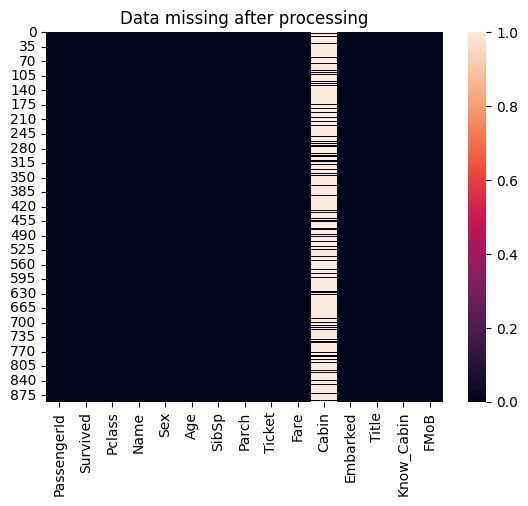

In [132]:
plt.figure()
sns.heatmap(df.isnull())
plt.title("Data missing after processing")
plt.show()

In [133]:
pd.get_dummies(df['Sex'])

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
886,False,True
887,True,False
888,True,False
889,False,True


In [134]:
pd.get_dummies(df['Embarked'])

,C,Q,S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
886,False,False,True
887,False,False,True
888,False,False,True
889,True,False,False


In [135]:
from sklearn.feature_extraction import FeatureHasher as fh

# FeatureHasher ожидает iterable of iterables
ticket_data = df['Ticket'].astype(str).values
ticket_samples = [[ticket] for ticket in ticket_data] # Список списков — формат для fh

nf = 20
hasher = fh(n_features=nf, input_type='string', alternate_sign=False, dtype=np.int32)
hashed_features = hasher.transform(ticket_samples)

ticket_m = hashed_features.toarray()
ticket_hash_df = pd.DataFrame(ticket_m, columns=[f'ticket_hach_{i}' for i in range(nf)])
print(f"Hashed features shape: {ticket_hash_df.shape}")
print("First 5 rows:")
print(ticket_hash_df.head())

ticket_hash_df = ticket_hash_df.reset_index(drop=True)
df_original_reset = df.reset_index(drop=True)
df_with_hash = pd.concat([df_original_reset, ticket_hash_df], axis=1)
print(f"New DataFrame shape: {df_with_hash.shape}")
print(f"Columns amount before: {df.shape[1]}, after: {df_with_hash.shape[1]}")
print(f"Columns added amount: {df_with_hash.shape[1]-df.shape[1]}")

Hashed features shape: (891, 20)
First 5 rows:
   ticket_hach_0  ticket_hach_1  ticket_hach_2  ticket_hach_3  ticket_hach_4  \
0              0              0              0              0              0   
1              0              0              0              0              0   
2              0              0              1              0              0   
3              1              0              0              0              0   
4              0              0              0              0              0   

   ticket_hach_5  ticket_hach_6  ticket_hach_7  ticket_hach_8  ticket_hach_9  \
0              0              0              0              0              0   
1              0              0              0              0              0   
2              0              0              0              0              0   
3              0              0              0              0              0   
4              0              0              0              0           

In [136]:
# Анализ целевой переменной (Survived)
import plotly.express as px

survived_data = df['Survived'].value_counts().reset_index()
survived_data.columns = ['Survived', 'Count']
survived_data['Status'] = survived_data['Survived'].map({0: 'Died', 1: 'Survived'})
survived_data['Percentage'] = (survived_data['Count'] / survived_data['Count'].sum() * 100).round(1)

fig = px.bar(survived_data, x='Status', y='Count', text='Percentage', color='Status', color_discrete_map={'Died': "#FC3C3C", 'Survived': "#33DB74"}, title='Death statistics')

fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(xaxis_title='Status', yaxis_title='Amount', showlegend=False, width=800, height=500)

fig.show()

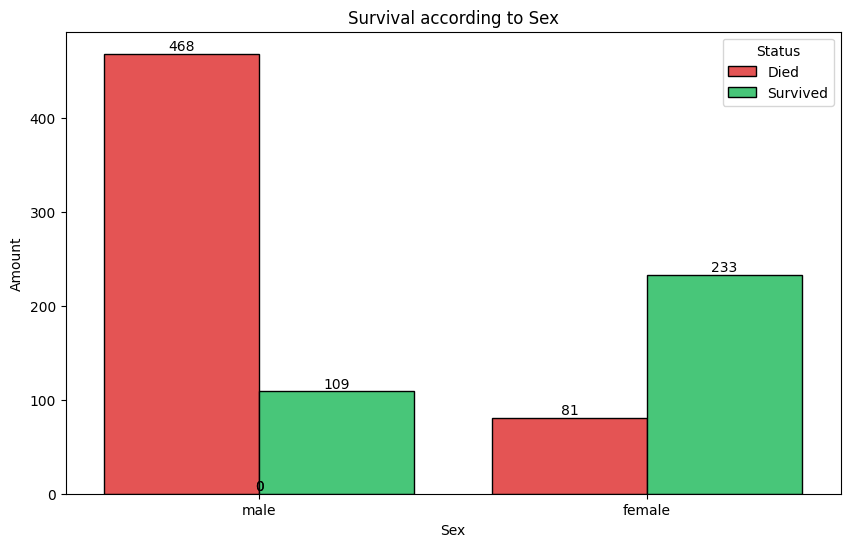

Survival by Sex
        count   mean
Sex                 
female    314  0.742
male      577  0.189
Female survived percentage: 74.2%
Male survived percentage: 18.9%


In [137]:
# Анализ по полу (Sex)
# Seaborn (группированный bar chart)
plt.figure(figsize=(10, 6))

ax = sns.countplot(data=df, x='Sex', hue='Survived', palette=['#FC3C3C', '#33DB74'], edgecolor='black')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)

plt.title('Survival according to Sex')
plt.xlabel('Sex')
plt.ylabel('Amount')
plt.legend(['Died', 'Survived'], title='Status')
plt.show()

print("Survival by Sex")
print(df.groupby('Sex')['Survived'].agg(['count', 'mean']).round(3))
print(f"Female survived percentage: {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"Male survived percentage: {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")

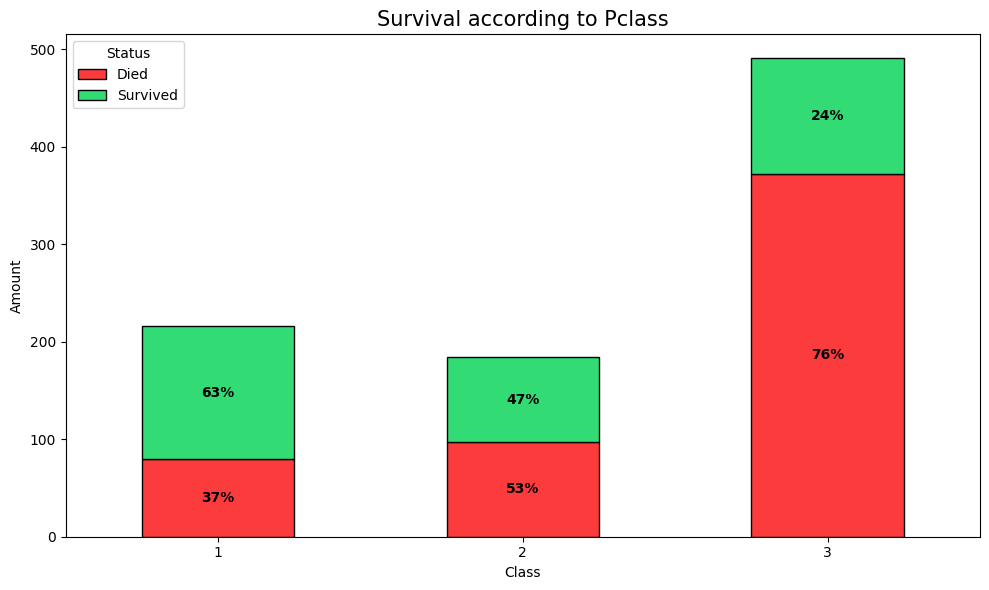

Survaval by Pclass
Pclass 1: 63.0% survived
Pclass 2: 47.3% survived
Pclass 3: 24.2% survived


In [138]:
# Анализ по классу (Pclass)
# Matplotlib (stacked bar chart)
pclass_survived = pd.crosstab(df['Pclass'], df['Survived'])
pclass_survived.columns = ['Died', 'Survived']

fig, ax = plt.subplots(figsize=(10, 6))

pclass_survived.plot(kind='bar', stacked=True, color=['#FC3C3C', '#33DB74'], edgecolor='black', ax=ax)

for i, (index, row) in enumerate(pclass_survived.iterrows()):
    total = row.sum()
    for j, (col, val) in enumerate(row.items()):
        if val > 0:
            percentage = val / total * 100
            y_pos = row[:j].sum() + val/2
            ax.text(i, y_pos, f'{percentage:.0f}%', ha='center', va='center', fontweight='bold')

plt.title("Survival according to Pclass", fontsize=15)
plt.xlabel("Class")
plt.ylabel("Amount")
plt.legend(title='Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Survaval by Pclass")
for pclass in [1, 2, 3]:
    survival_rate = df[df['Pclass']==pclass]['Survived'].mean() * 100
    print(f"Pclass {pclass}: {survival_rate:.1f}% survived")

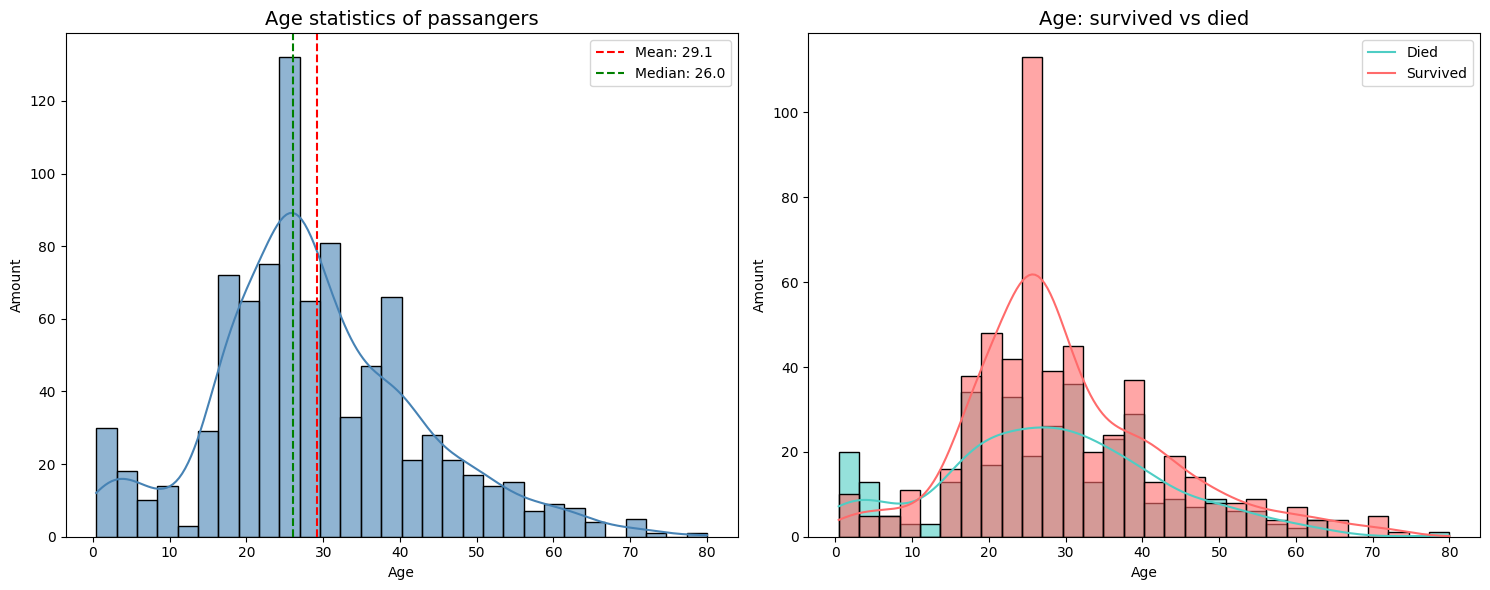

In [139]:
# Распределение возраста (Age)
# Seaborn (гистограмма с KDE)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=df, x='Age', bins=30, kde=True, ax=axes[0], color='steelblue', alpha=0.6)
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df['Age'].mean():.1f}')
axes[0].axvline(df['Age'].median(), color='green', linestyle='--', label=f'Median: {df['Age'].median():.1f}')
axes[0].set_title('Age statistics of passangers', fontsize=14)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Amount')
axes[0].legend()

sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, palette=['#FF6B6B', '#4ECDC4'], alpha=0.6, ax=axes[1])
axes[1].set_title('Age: survived vs died', fontsize=14)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Amount')
axes[1].legend(['Died', 'Survived'])

plt.tight_layout()
plt.show()

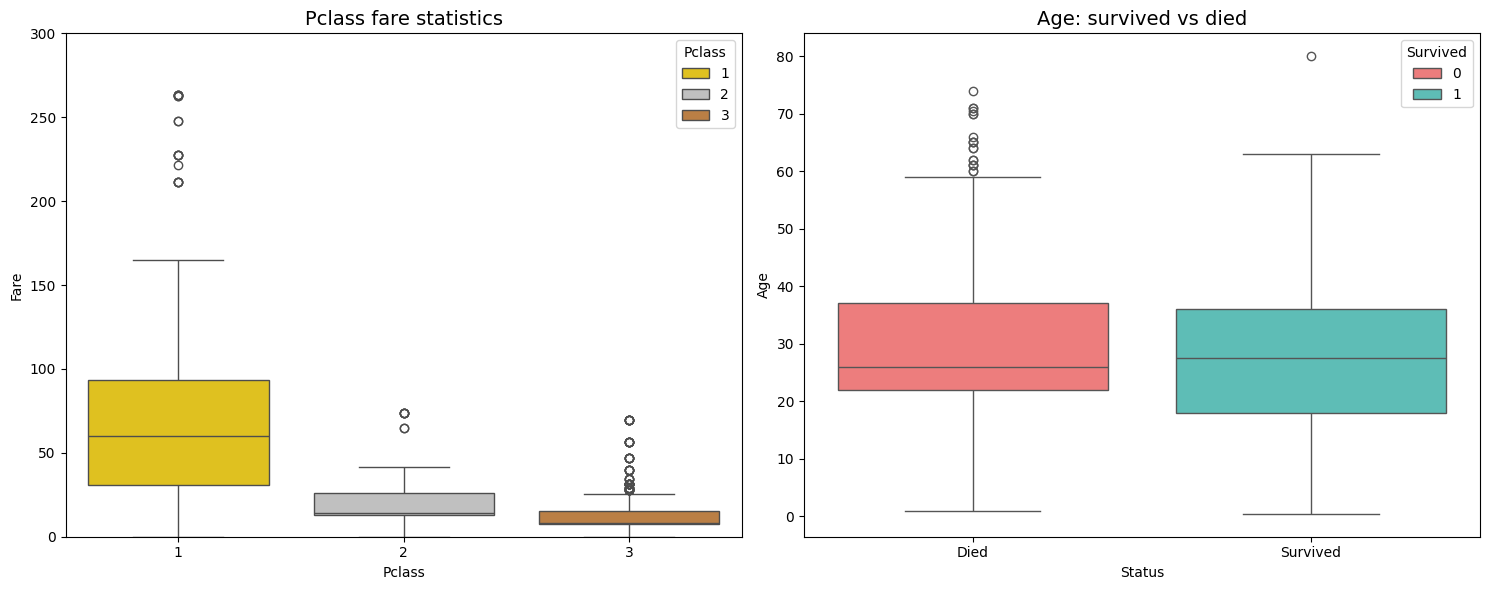

Outliers of Fare analysis
Outliers of Fare amount: 116
Max Fare: $512.33


In [140]:
# Box plot для поиска выбросов
# Seaborn (ящики с усами)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, x='Pclass', y='Fare', hue='Pclass', ax=axes[0], palette=['gold', 'silver', '#CD7F32'])
axes[0].set_title('Pclass fare statistics', fontsize=14)
axes[0].set_xlabel('Pclass')
axes[0].set_ylabel('Fare')
axes[0].set_ylim(0, 300)

sns.boxplot(data=df, x='Survived', y='Age', hue='Survived', ax=axes[1], palette=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Age: survived vs died', fontsize=14)
axes[1].set_xlabel('Status')
axes[1].set_xticks([0, 1], labels=['Died', 'Survived'])
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

print("Outliers of Fare analysis")
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Fare'] < Q1 - 1.5*IQR) | (df['Fare'] > Q3 + 1.5*IQR)]
print(f'Outliers of Fare amount: {len(outliers)}')
print(f'Max Fare: ${df['Fare'].max():.2f}')

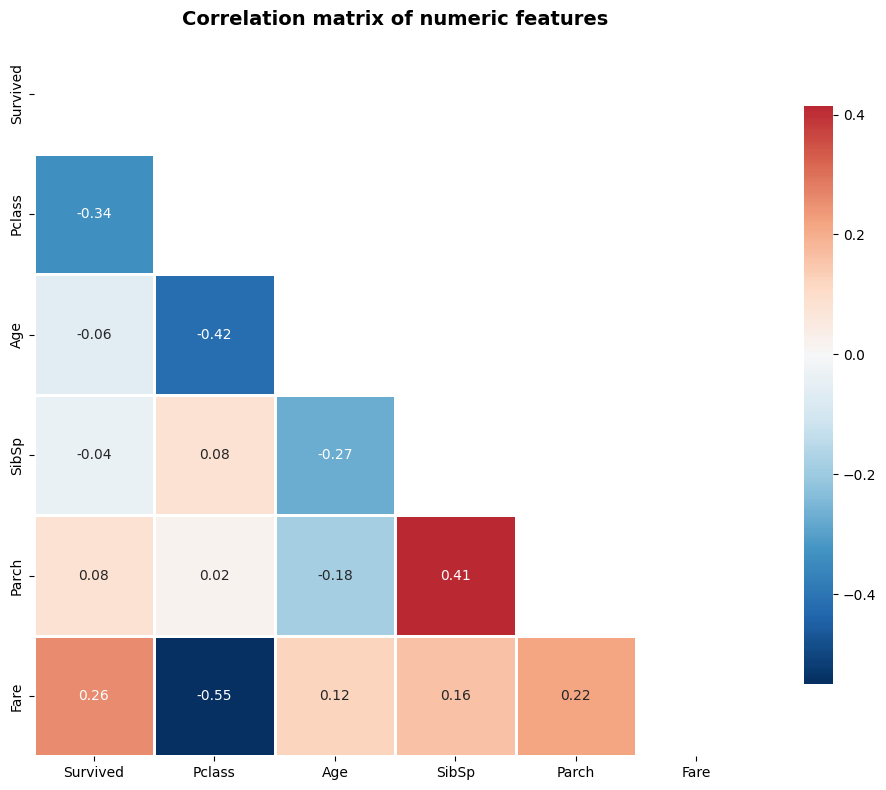

Strong correlations with Survived
Fare: 0.257 (positive, moderate)
Parch: 0.082 (positive, low)
SibSp: -0.035 (negative, low)
Age: -0.063 (negative, low)
Pclass: -0.338 (negative, strong)


In [141]:
# Тепловая карта корреляций
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=1, mask=mask, cbar_kws={'shrink': 0.8})

plt.title('Correlation matrix of numeric features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Strong correlations with Survived")
corr_with_target = corr_matrix['Survived'].sort_values(ascending=False)
for feat, corr in corr_with_target.items():
    if feat != 'Survived':
        direction = "positive" if corr > 0 else "negative"
        strength = "strong" if abs(corr) > 0.3 else "moderate" if abs(corr) > 0.1 else "low"
        print(f'{feat}: {corr:.3f} ({direction}, {strength})')

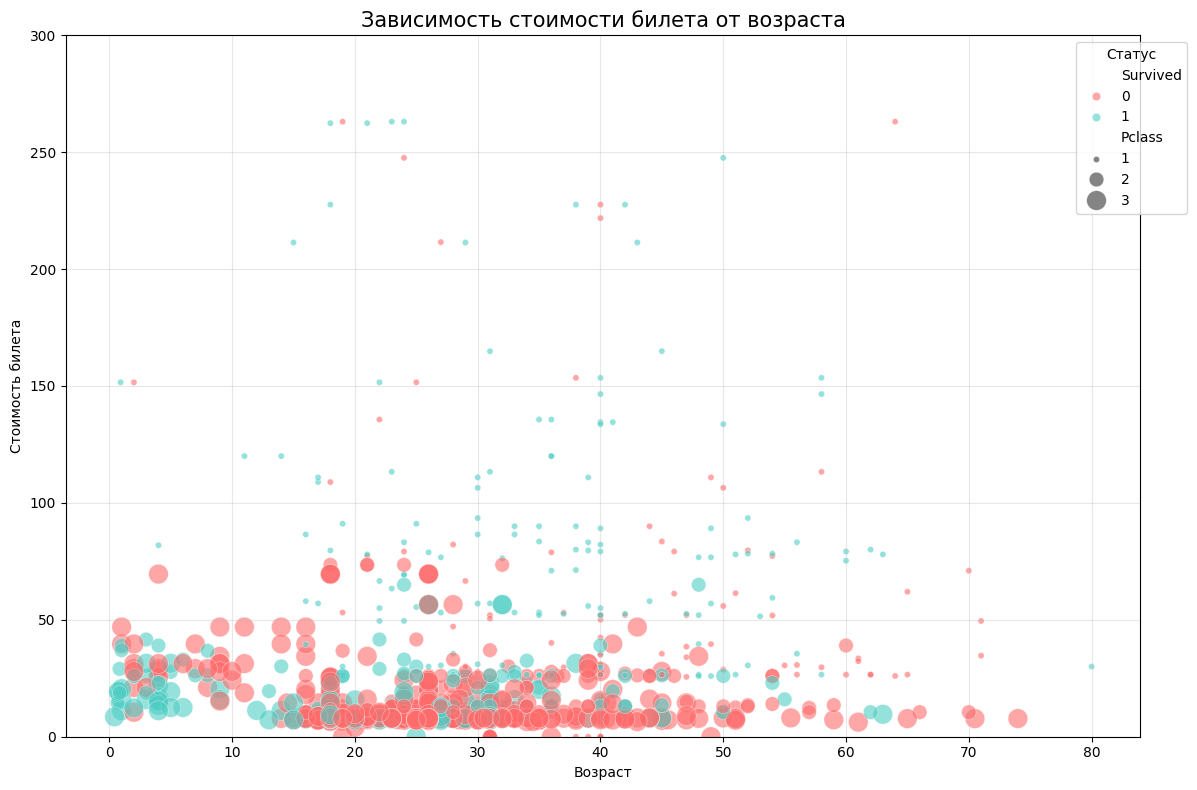

In [142]:
# Scatter plot (Age vs Fare)
plt.figure(figsize=(12, 8))

sns.scatterplot(data=df, x='Age', y='Fare', 
                hue='Survived', 
                size='Pclass',
                sizes=(20, 200),
                palette=['#FF6B6B', '#4ECDC4'],
                alpha=0.6)

plt.title('Зависимость стоимости билета от возраста', fontsize=15)
plt.xlabel('Возраст')
plt.ylabel('Стоимость билета')
plt.ylim(0, 300)
plt.legend(title='Статус', bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Kseniya Morozova\AppData\Local\Temp\ipykernel_16288\1299425583.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Pclass', y='Fare', ax=axes[1],


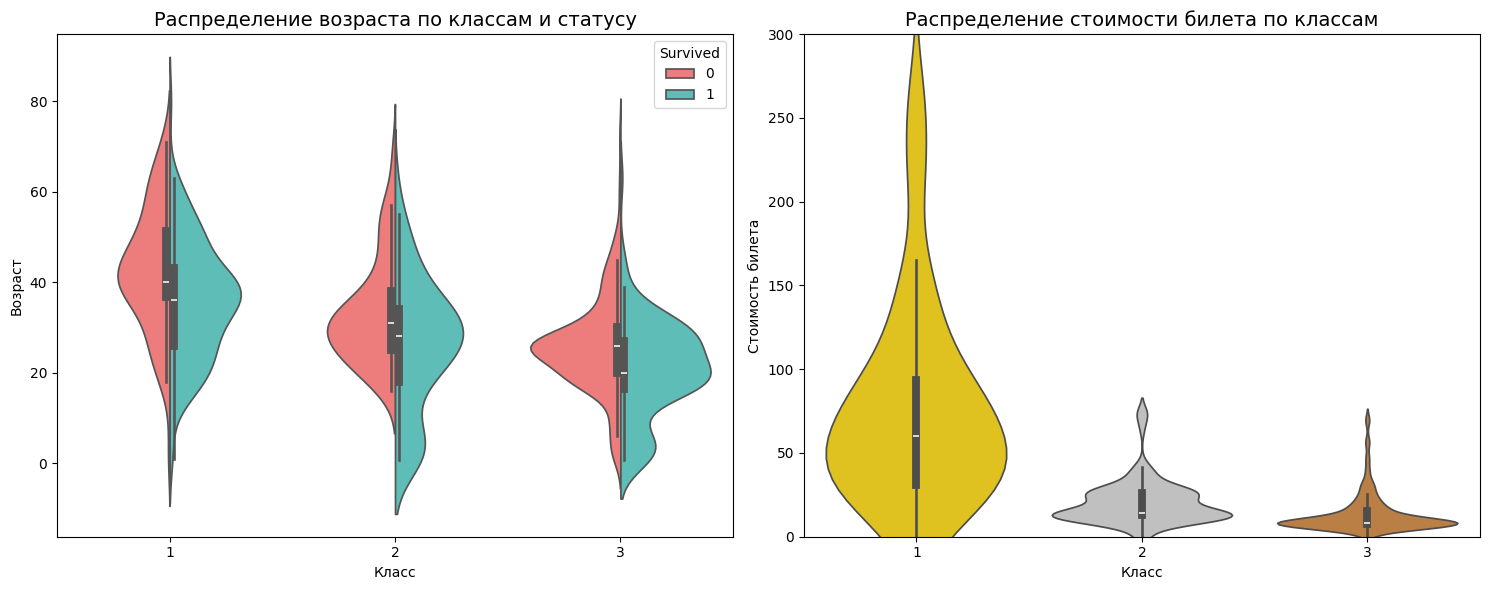

In [143]:
# Violin plot (комбинирует box plot и KDE)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.violinplot(data=df, x='Pclass', y='Age', hue='Survived',
               split=True,
               palette=['#FF6B6B', '#4ECDC4'],
               ax=axes[0])
axes[0].set_title('Распределение возраста по классам и статусу', fontsize=14)
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Возраст')

sns.violinplot(data=df, x='Pclass', y='Fare', ax=axes[1],
               palette=['gold', 'silver', '#CD7F32'])
axes[1].set_title('Распределение стоимости билета по классам', fontsize=14)
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Стоимость билета')
axes[1].set_ylim(0, 300)

plt.tight_layout()
plt.show()

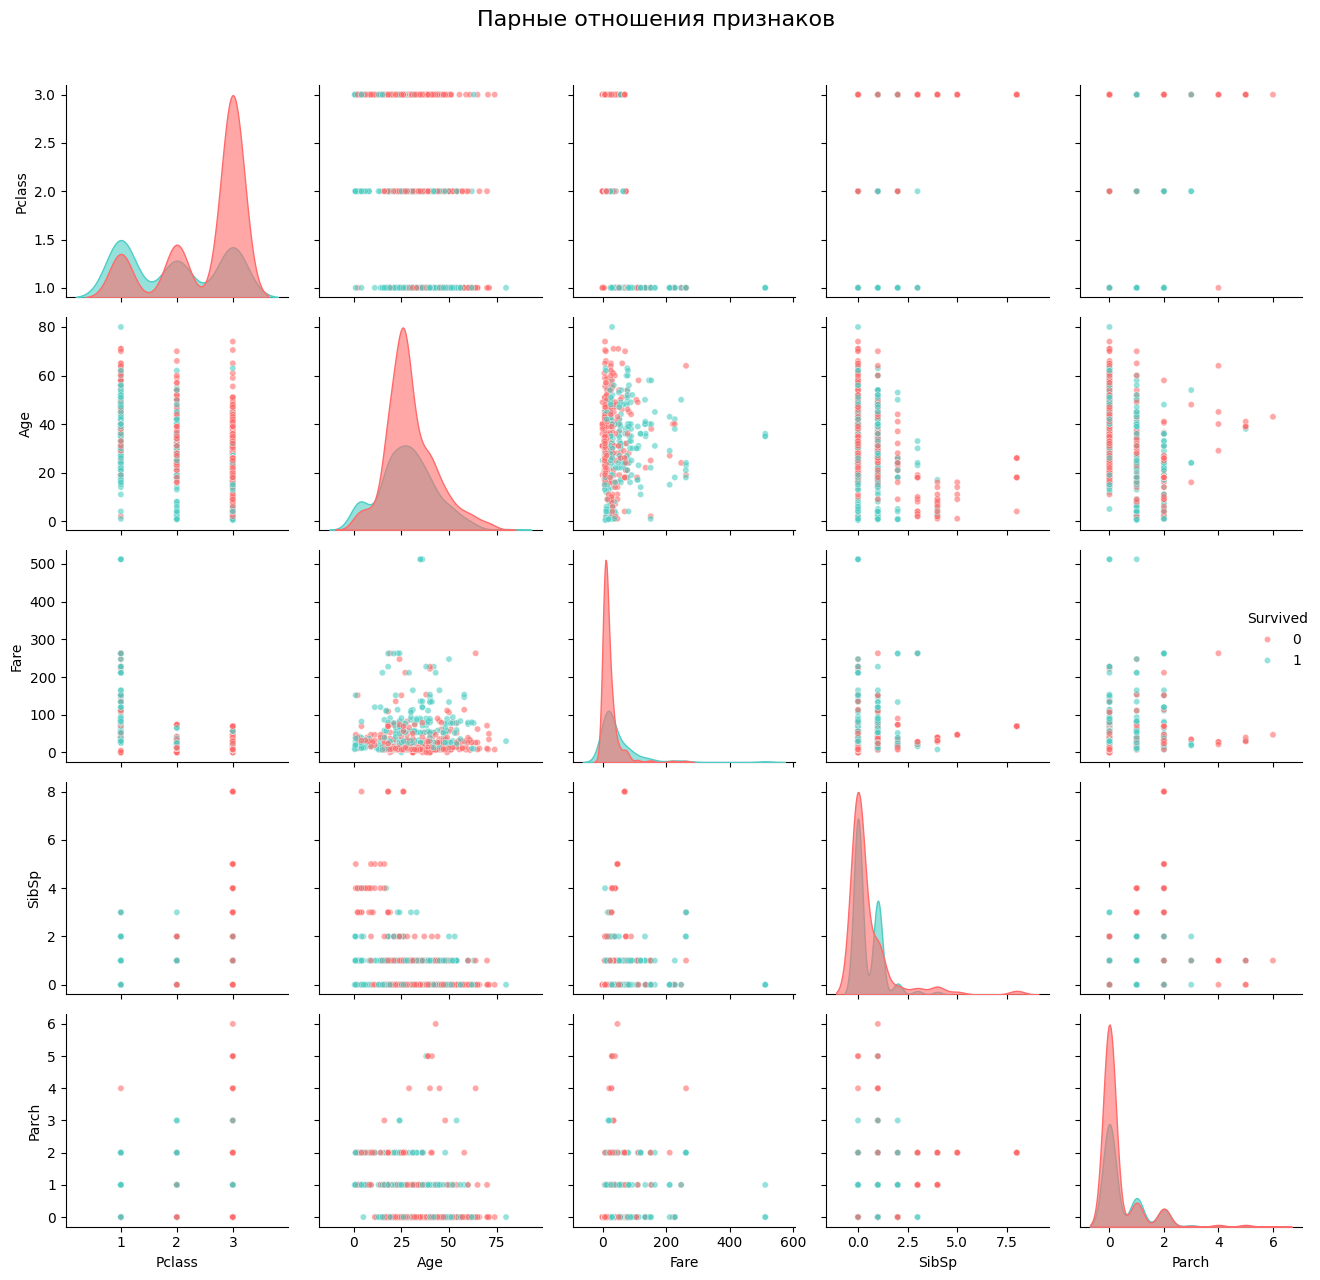

In [144]:
# Pairplot (все признаки вместе)
cols_for_pair = ['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch']

g = sns.pairplot(df[cols_for_pair], 
                 hue='Survived',
                 palette=['#FF6B6B', '#4ECDC4'],
                 diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 20},
                 diag_kws={'alpha': 0.6})

g.fig.suptitle('Парные отношения признаков', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [145]:
# Интерактивный график Plotly с hover_data
fig = px.scatter(df, 
                 x='Age', 
                 y='Fare',
                 color='Survived',
                 size='Pclass',
                 hover_data=['Sex', 'Pclass', 'Embarked'],
                 title='Интерактивный анализ пассажиров Titanic',
                 labels={'Survived': 'Выжил', 'Age': 'Возраст', 'Fare': 'Стоимость билета'},
                 color_discrete_map={0: '#FF6B6B', 1: '#4ECDC4'})

fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.update_layout(
    hoverlabel=dict(
        bgcolor="white",
        font_size=12,
        font_family="Arial"
    ),
    width=1000,
    height=600
)

fig.show()

Что я поняла про датасет?

1) 891 пассажир, выжило 38.4% (342), погибло 61.6% (549)

2) Пропуски: Age (20%), Cabin (77%), Embarked (2 записи)

3) Класс обслуживания важен: 1 класс → ~63% выживших, 3 класс → ~24%

4) Пол — главный фактор: женщины выжили 74%, мужчины 19%

5) Возраст: от 0.4 до 80 лет, медиана ~28 лет

6) Стоимость билета от 0 до 512 денег, есть выбросы

7) Размер семьи: одиночки выживают хуже, чем семьи из 2-4 человек

Гипотезы:

* "Женщины и дети в первую очередь" сработало: женщины + дети до 15 лет выживали чаще

* Социальный статус (класс + стоимость билета) определил приоритет эвакуации

* Большие семьи (5+ человек) выживали реже — сложнее эвакуироваться всем вместе

* Порт посадки косвенно влияет через корреляцию с классом

Что дальше?

Я бы сделала упор на:

- Модели: Logistic Regression (baseline) → Random Forest → XGBoost

- То, что предсказывать: бинарная классификация (выжил/погиб)

- Метрики: Accuracy, F1-score (с учётом дисбаланса классов)

Использование AI

Я искала, как работает FeatureHasher, чем отличается skewness от kurtosis, как обработать пропуски в Cabin, формулу IQR для выбросов.
В качестве проверки изучала теорию, сверяла с документацией, тестировала код на тестовых выборках.
Дописывала руками обоснования выбора median вместо mean для Age, группировку редких титулов в "Other", интерпретацию корреляций. Также много пришлось разбираться с синтаксическими ошибками.
В целом AI (я использовала по большей части DeepSeek) очень помогает изучать что-то новое. Существенно это ощущается по части работы с синтаксисом и идеями.